# **Đồ án Lab 01: Xử lý ảnh bằng Ma trận**

**Môn học:** Toán ứng dụng và thống kê 

**Nhóm sinh viên:** 
- 21120565 - Trần Văn Thông
- 23120248 - Nguyễn Mạnh Hà
- 23120344 - Đặng Dương Thanh Quang
- 23120367 - Trần Ngọc Diễm Thúy
- 23120387 - Nguyễn Duy Tú

---

## **1. Khai báo thư viện và Module**

Chúng em chia dự án thành các module nhỏ để dễ quản lý:
- `basic_ops`: Các phép toán pixel cơ bản.
- `convolution`: Các phép toán tích chập ma trận.
- `edge_detect`: Thuật toán phát hiện biên cạnh.

In [1]:
# ── Cell 1: Import ──────────────────────────────
from src.io_handler import read_image, save_image, show_comparison, generate_report, matrix_info
from src.basic_ops import brighten, adjust_contrast, to_grayscale
from src.convolution import apply_kernel, gaussian_blur, sharpen    # Thành viên 3
# from src.edge_detect import sobel_edges                    # Thành viên 4

## **2. Đọc dữ liệu ảnh**

Ảnh được đọc dưới dạng ma trận đa chiều (NumPy array) để thực hiện các phép toán đại số tuyến tính.

In [2]:
# ── Cell 2: Đọc ảnh đầu vào ─────────────────────
img = read_image("data/input/sample.jpg", mode="color")

## **3. Tăng sáng bằng phép cộng ma trận**

Ý tưởng là cộng cùng một hằng số vào tất cả pixel. Khi đó toàn bộ ảnh sẽ sáng hơn hoặc tối hơn một cách đồng đều.

Công thức:

`I'(x, y) = I(x, y) + c`

Trong đó:
- `c` là hằng số cộng vào mọi pixel.
    - Nếu `c > 0` thì ảnh sáng lên.
    - Nếu `c < 0` thì ảnh tối đi.


────────────────────────────────────────
  Ảnh sau khi tăng sáng
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 40.00 / 255.00
  Trung bình : 147.22
────────────────────────────────────────



────────────────────────────────────────
  Ảnh sau khi tăng sáng
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 40.00 / 255.00
  Trung bình : 147.22
────────────────────────────────────────


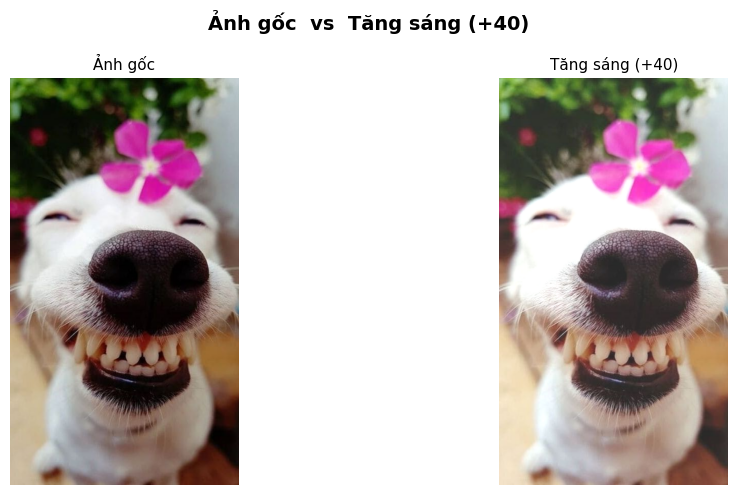

 Đã lưu ảnh: data\output\brightened_sample.jpg


In [3]:
# ── Cell 3: Tăng sáng ───────────────────────────
# Tăng sáng bằng cách cộng một giá trị vào tất cả pixel
brightness_value = 40
bright_image = brighten(img, brightness_value)

# Hiển thị thông tin ma trận và so sánh ảnh
matrix_info(bright_image, label='Ảnh sau khi tăng sáng')
show_comparison(
    img,
    bright_image,
    title_orig='Ảnh gốc',
    title_proc=f'Tăng sáng (+{brightness_value})'
)

# Lưu ảnh đã xử lý
save_image(bright_image, 'data/output/brightened_sample.jpg')

## **4. Điều chỉnh tương phản bằng phép nhân ma trận**

Điều chỉnh tương phản bằng cách nhân toàn bộ ma trận ảnh với một hệ số `k`.

Công thức:

`I'(x, y) = I(x, y) * k`

- Nếu `k > 1` thì mức sáng được khuếch đại mạnh hơn, ảnh nhìn gắt hơn.
- Nếu `0 < k < 1` thì mức sáng bị nén lại, ảnh nhìn dịu hơn.


────────────────────────────────────────
  Ảnh sau khi điều chỉnh tương phản
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 140.21
────────────────────────────────────────


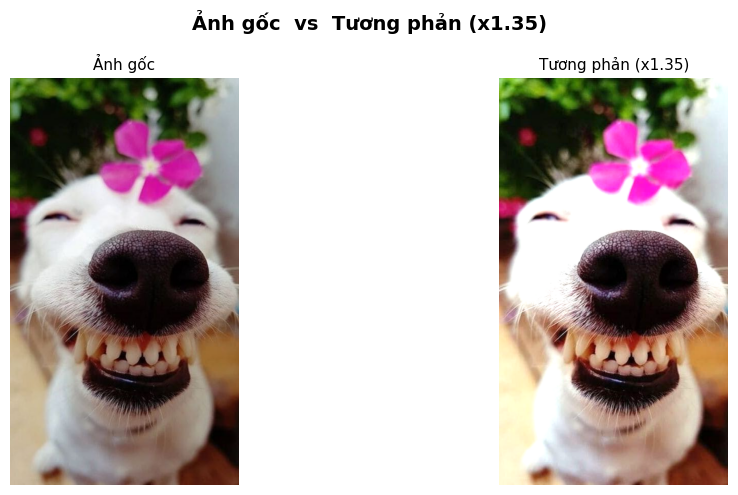


────────────────────────────────────────
  Ảnh sau khi điều chỉnh tương phản
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 140.21
────────────────────────────────────────


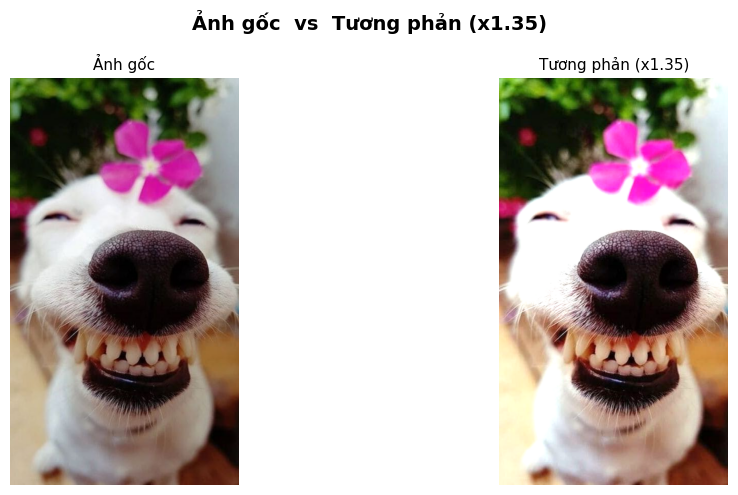

 Đã lưu ảnh: data\output\contrast_sample.jpg


In [4]:
# ── Cell 4: Điều chỉnh tương phản ─────────────────
# Điều chỉnh tương phản bằng cách nhân một hệ số vào tất cả pixel
contrast_factor = 1.35
contrast_image = adjust_contrast(img, contrast_factor)

# Hiển thị thông tin ma trận và so sánh ảnh
matrix_info(contrast_image, label='Ảnh sau khi điều chỉnh tương phản')
show_comparison(
    img,
    contrast_image,
    title_orig='Ảnh gốc',
    title_proc=f'Tương phản (x{contrast_factor})'
)

# Lưu ảnh đã xử lý
save_image(contrast_image, 'data/output/contrast_sample.jpg')

## **5. Chuyển ảnh màu sang ảnh xám bằng tổ hợp tuyến tính**

Ảnh màu gồm 3 kênh B, G, R. Mục tiêu là quy 3 giá trị màu của mỗi pixel về một giá trị mức xám duy nhất.

Do ảnh được đọc theo thứ tự **BGR**, công thức trong phần này được viết theo đúng thứ tự đó:

`Gray = 0.114 * B + 0.587 * G + 0.299 * R`

Đây là phép tổ hợp tuyến tính có trọng số, cho thấy mỗi kênh đóng góp khác nhau vào độ sáng cảm nhận.


────────────────────────────────────────
  Ảnh grayscale
  Kích thước : (800, 450)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 254.00
  Trung bình : 109.27
────────────────────────────────────────



────────────────────────────────────────
  Ảnh grayscale
  Kích thước : (800, 450)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 254.00
  Trung bình : 109.27
────────────────────────────────────────


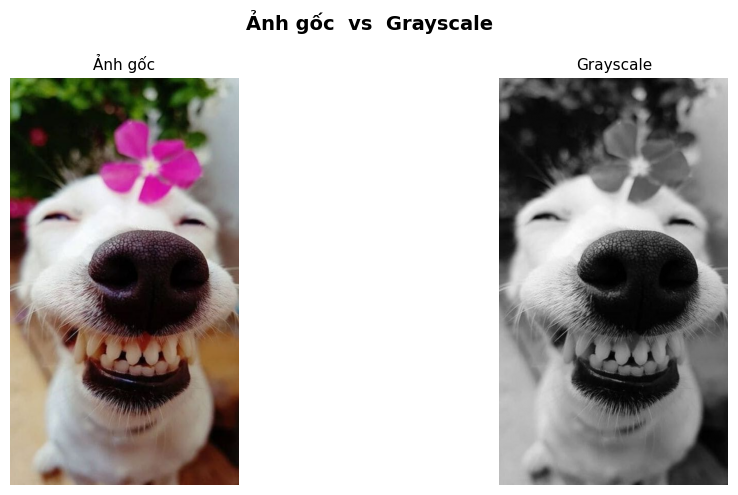

 Đã lưu ảnh: data\output\grayscale_sample.jpg


In [5]:
# ── Cell 5: Chuyển sang grayscale ─────────────────
# Chuyển ảnh màu sang grayscale bằng cách tính trung bình có trọng số của các kênh màu
gray_image = to_grayscale(img)

# Hiển thị thông tin ma trận và so sánh ảnh
matrix_info(gray_image, label='Ảnh grayscale')
show_comparison(
    img,
    gray_image,
    title_orig='Ảnh gốc',
    title_proc='Grayscale',
    cmap='gray'
)

# Lưu ảnh đã xử lý
save_image(gray_image, 'data/output/grayscale_sample.jpg')

## **6. Tích chập (Convolution) - Làm mờ ảnh bằng Gaussian Blur**

Tích chập là phép toán cốt lõi trong xử lý ảnh. Ý tưởng cơ bản là:
- Sử dụng một ma trận nhỏ gọi là **kernel** để áp dụng trên toàn bộ ảnh.
- Tại mỗi vị trí, ta tính tổng tích của kernel và vùng ảnh tương ứng.
- Công thức: `I'(x, y) = Σ Σ K(i, j) * I(x+i, y+j)`

**Gaussian Blur** là một ứng dụng phổ biến của tích chập:
- Sử dụng kernel Gaussian để làm mờ ảnh.
- Giúp giảm nhiễu và chuẩn bị cho các bước xử lý tiếp theo.
- Công thức Gaussian 2D: `G(x, y) = (1 / (2π*σ²)) * exp(-(x² + y²) / (2σ²))`


────────────────────────────────────────
  Ảnh sau khi áp dụng Gaussian Blur
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 254.00
  Trung bình : 108.05
────────────────────────────────────────



────────────────────────────────────────
  Ảnh sau khi áp dụng Gaussian Blur
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 254.00
  Trung bình : 108.05
────────────────────────────────────────


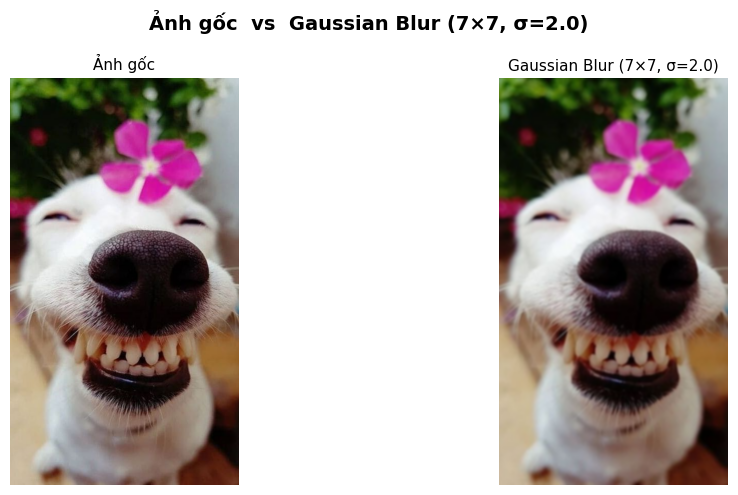

 Đã lưu ảnh: data\output\blur_sample.jpg


In [6]:
# ── Cell 6: Gaussian Blur ──────────────────────────
# Áp dụng Gaussian Blur lên ảnh
blur_image = gaussian_blur(img, kernel_size=7, sigma=2.0)

# Hiển thị thông tin ma trận và so sánh ảnh
matrix_info(blur_image, label='Ảnh sau khi áp dụng Gaussian Blur')
show_comparison(
    img,
    blur_image,
    title_orig='Ảnh gốc',
    title_proc='Gaussian Blur (7×7, σ=2.0)'
)

# Lưu ảnh đã xử lý
save_image(blur_image, 'data/output/blur_sample.jpg')

## **7. Làm sắc nét ảnh bằng Laplacian Sharpening**

Làm sắc nét ảnh sử dụng **Laplacian operator**:
- Laplacian là một toán tử vi phân bậc 2 phát hiện biến thiên cường độ nhanh.
- Ý tưởng: cộng kết quả Laplacian (nhân với hệ số strength) vào ảnh gốc.
- Công thức: `I_sharp = I_original + strength * Laplacian(I)`

**Kernel Laplacian (4-láng giềng):**
```
[  0, -1,  0 ]
[ -1,  4, -1 ]
[  0, -1,  0 ]
```

- strength càng lớn → ảnh càng sắc nét, nhưng cũng tăng nhiễu.
- strength = 0 → không làm sắc nét.
- strength = 1 → làm sắc nét bình thường.


────────────────────────────────────────
  Ảnh sau khi làm sắc nét
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 177.55
────────────────────────────────────────



────────────────────────────────────────
  Ảnh sau khi làm sắc nét
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 177.55
────────────────────────────────────────


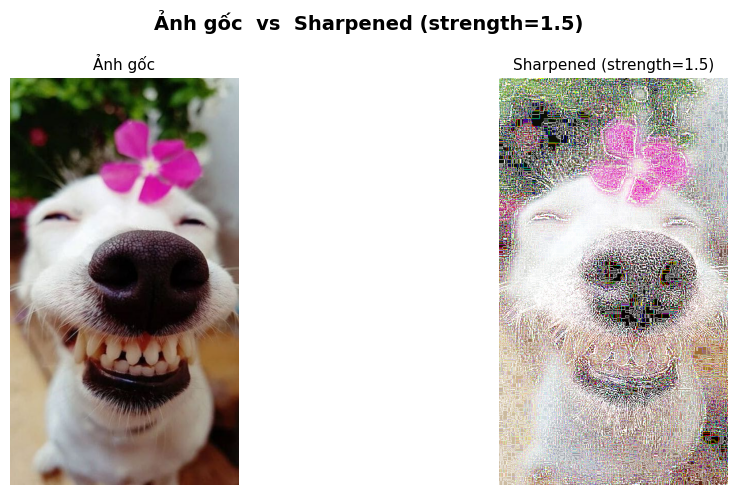

 Đã lưu ảnh: data\output\sharp_sample.jpg


In [7]:
# ── Cell 7: Laplacian Sharpening ───────────────────
# Áp dụng Sharpening lên ảnh
sharp_image = sharpen(img, strength=1.5, kernel_type='laplacian')

# Hiển thị thông tin ma trận và so sánh ảnh
matrix_info(sharp_image, label='Ảnh sau khi làm sắc nét')
show_comparison(
    img,
    sharp_image,
    title_orig='Ảnh gốc',
    title_proc='Sharpened (strength=1.5)'
)

# Lưu ảnh đã xử lý
save_image(sharp_image, 'data/output/sharp_sample.jpg')